In [1]:
# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('ggplot')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

print("Libraries loaded successfully")

Libraries loaded successfully


# Legendre Coefficient Distribution Analysis

This notebook analyzes the distribution of Legendre coefficient samples generated by the
`exfor_to_endf_sampling_v2.py` pipeline.

**Why non-normal distributions are expected:**
The pipeline applies Gaussian noise to EXFOR data, then fits Legendre coefficients via weighted
ridge regression. Despite Gaussian input noise, the output coefficients are **not expected to be
normally distributed** due to:
- **Lognormal per-experiment normalization** — multiplicative, asymmetric scaling
- **Ridge regularization** (l^4 penalty) — biases coefficients toward zero asymmetrically
- **Heteroskedastic noise** — band-based discrepancy model gives different variance per angular region
- **Data-driven degree selection** (AICc) — different samples may use different polynomial degrees, creating mixture distributions

The observed negative skewness and leptokurtic tails are consistent with the pipeline design.

In [2]:
# === USER CONFIGURATION ===
# Set the energy (MeV) to analyze — the notebook will find the closest available energy
ENERGY_MEV = 1.51

# Path to the CSV file generated by the exfor_to_endf_sampling_v2.py pipeline
CSV_PATH = '/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/legendre_coefficients_all_samples.csv'

In [3]:
# Cell 2: Load the data
df = pd.read_csv(CSV_PATH)

print(f"Data loaded from: {CSV_PATH}")
print(f"  Total rows: {len(df):,}")
print(f"  Columns: {list(df.columns)}")
print(f"\nData structure:")
print(f"  Sample indices: {df['sample_idx'].min()} to {df['sample_idx'].max()}")
print(f"    (0 = nominal, 1-N = MC samples)")
print(f"  Energy points: {df['energy_index'].nunique()}")
print(f"  Energy range: {df['energy_mev'].min():.4f} - {df['energy_mev'].max():.4f} MeV")

# Identify coefficient columns
coeff_cols = [col for col in df.columns if col.startswith('a_')]
max_degree = len(coeff_cols)
print(f"  Maximum Legendre degree: {max_degree}")

Data loaded from: /mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/legendre_coefficients_all_samples.csv
  Total rows: 1,513,512
  Columns: ['sample_idx', 'energy_index', 'energy_mev', 'a_1', 'a_2', 'a_3', 'a_4', 'a_5', 'a_6', 'a_7', 'a_8']

Data structure:
  Sample indices: 0 to 1000
    (0 = nominal, 1-N = MC samples)
  Energy points: 1512
  Energy range: 1.0000 - 3.0000 MeV
  Maximum Legendre degree: 8


In [4]:
# Cell 3: Explore available energies
print("Available energy points:\n")
energy_summary = df.groupby(['energy_index', 'energy_mev']).size().reset_index(name='n_samples')
energy_summary = energy_summary.sort_values('energy_mev')

for idx, row in energy_summary.iterrows():
    print(f"  Index {int(row['energy_index']):3d}: {row['energy_mev']:8.5f} MeV ({row['n_samples']} samples)")
    
print(f"\nTotal unique energies: {len(energy_summary)}")

Available energy points:



  Index 2376:  1.00000 MeV (1001.0 samples)
  Index 2377:  1.00100 MeV (1001.0 samples)
  Index 2378:  1.00200 MeV (1001.0 samples)
  Index 2379:  1.00300 MeV (1001.0 samples)
  Index 2380:  1.00400 MeV (1001.0 samples)
  Index 2381:  1.00500 MeV (1001.0 samples)
  Index 2382:  1.00600 MeV (1001.0 samples)
  Index 2383:  1.00700 MeV (1001.0 samples)
  Index 2384:  1.00800 MeV (1001.0 samples)
  Index 2385:  1.00900 MeV (1001.0 samples)
  Index 2386:  1.01000 MeV (1001.0 samples)
  Index 2387:  1.01100 MeV (1001.0 samples)
  Index 2388:  1.01200 MeV (1001.0 samples)
  Index 2389:  1.01300 MeV (1001.0 samples)
  Index 2390:  1.01400 MeV (1001.0 samples)
  Index 2391:  1.01500 MeV (1001.0 samples)
  Index 2392:  1.01600 MeV (1001.0 samples)
  Index 2393:  1.01700 MeV (1001.0 samples)
  Index 2394:  1.01800 MeV (1001.0 samples)
  Index 2395:  1.01900 MeV (1001.0 samples)
  Index 2396:  1.02000 MeV (1001.0 samples)
  Index 2397:  1.02100 MeV (1001.0 samples)
  Index 2398:  1.02200 MeV (1001

In [5]:
# Cell 4: Helper function to detect actual fitted degree
def detect_actual_degree(coeffs):
    """
    Detect the actual fitted degree by finding the last non-zero coefficient.
    Returns the degree (1-based) or 0 if all coefficients are zero.
    """
    # Work backwards from highest degree
    for i in range(len(coeffs) - 1, -1, -1):
        if abs(coeffs[i]) > 1e-12:  # Small threshold for numerical zeros
            return i + 1  # Return 1-based degree (a_1 = degree 1)
    return 0  # All zeros

def get_nonzero_mask(df_subset, coeff_cols):
    """
    For each coefficient column, create a mask that is True only for samples
    where that degree was actually fitted (not just zero-padded).
    """
    masks = {}
    for l_idx, col in enumerate(coeff_cols):
        l_degree = l_idx + 1  # a_1 = degree 1, etc.
        
        # A coefficient is "real" if the actual fitted degree >= l_degree
        actual_degrees = df_subset[coeff_cols].apply(detect_actual_degree, axis=1)
        masks[col] = actual_degrees >= l_degree
        
    return masks

print("Helper functions defined")

Helper functions defined


In [6]:
# Cell 5: Select energy to analyze (using ENERGY_MEV from configuration)
available_energies = np.sort(df['energy_mev'].unique())
closest_idx = np.argmin(np.abs(available_energies - ENERGY_MEV))
selected_energy_mev = available_energies[closest_idx]

tolerance = 0.001  # MeV
if abs(selected_energy_mev - ENERGY_MEV) > tolerance:
    print(f"WARNING: Requested {ENERGY_MEV:.5f} MeV not found exactly.")
    print(f"  Using closest available energy: {selected_energy_mev:.5f} MeV "
          f"(delta = {abs(selected_energy_mev - ENERGY_MEV)*1e3:.2f} keV)")
else:
    print(f"Selected energy: {selected_energy_mev:.5f} MeV")

# Find corresponding energy_index
selected_energy_idx = df.loc[df['energy_mev'] == selected_energy_mev, 'energy_index'].iloc[0]
print(f"  Energy index: {selected_energy_idx}")

# Filter data for this energy (excluding nominal sample_idx=0)
df_energy = df[(df['energy_index'] == selected_energy_idx) & (df['sample_idx'] > 0)].copy()

print(f"\nFiltered data:")
print(f"  Total MC samples: {len(df_energy)}")
print(f"  Coefficient columns: {coeff_cols}")

# Get the nominal values for reference
df_nominal = df[(df['energy_index'] == selected_energy_idx) & (df['sample_idx'] == 0)]
if len(df_nominal) > 0:
    nominal_coeffs = df_nominal[coeff_cols].values[0]
    print(f"\nNominal coefficients:")
    for col, val in zip(coeff_cols, nominal_coeffs):
        print(f"  {col}: {val:12.6e}")
else:
    nominal_coeffs = None
    print("\nWarning: No nominal coefficients found for this energy")

Selected energy: 1.51000 MeV
  Energy index: 2886

Filtered data:
  Total MC samples: 1000
  Coefficient columns: ['a_1', 'a_2', 'a_3', 'a_4', 'a_5', 'a_6', 'a_7', 'a_8']

Nominal coefficients:
  a_1: 2.458069e-01
  a_2: 2.949123e-01
  a_3: 9.038417e-02
  a_4: 1.945816e-02
  a_5: 6.492752e-03
  a_6: 2.750774e-03
  a_7: 0.000000e+00
  a_8: 0.000000e+00


In [7]:
# Cell 6: Analyze actual fitted degrees
actual_degrees = df_energy[coeff_cols].apply(detect_actual_degree, axis=1)

print("Distribution of fitted degrees:")
degree_counts = actual_degrees.value_counts().sort_index()
for degree, count in degree_counts.items():
    print(f"  Degree {degree}: {count:4d} samples ({count/len(df_energy)*100:5.1f}%)")

# Create masks for non-padded coefficients
nonzero_masks = get_nonzero_mask(df_energy, coeff_cols)

print("\nNon-zero coefficient counts:")
for col, mask in nonzero_masks.items():
    n_nonzero = mask.sum()
    print(f"  {col}: {n_nonzero:4d} samples ({n_nonzero/len(df_energy)*100:5.1f}%)")

Distribution of fitted degrees:
  Degree 6: 1000 samples (100.0%)



Non-zero coefficient counts:
  a_1: 1000 samples (100.0%)
  a_2: 1000 samples (100.0%)
  a_3: 1000 samples (100.0%)
  a_4: 1000 samples (100.0%)
  a_5: 1000 samples (100.0%)
  a_6: 1000 samples (100.0%)
  a_7:    0 samples (  0.0%)
  a_8:    0 samples (  0.0%)


In [8]:
# Cell 7: Statistical analysis function
def analyze_coefficient_distribution(data, coeff_name, mask, nominal_value=None):
    """
    Perform comprehensive distribution analysis for a single coefficient.
    
    Parameters
    ----------
    data : array-like
        Coefficient values
    coeff_name : str
        Name of the coefficient (for labeling)
    mask : array-like of bool
        Mask indicating which values are real (not zero-padded)
    nominal_value : float, optional
        Nominal (best-fit) value for reference
    
    Returns
    -------
    dict
        Dictionary of statistical metrics
    """
    # Filter to non-padded values only
    real_data = data[mask]
    
    if len(real_data) < 3:
        return {
            'coeff': coeff_name,
            'n_samples': len(real_data),
            'mean': np.nan,
            'std': np.nan,
            'skewness': np.nan,
            'kurtosis': np.nan,
            'shapiro_p': np.nan,
            'ks_p': np.nan,
            'anderson_stat': np.nan,
            'is_normal_shapiro': False,
            'is_normal_ks': False,
        }
    
    # Basic statistics
    mean_val = np.mean(real_data)
    std_val = np.std(real_data, ddof=1)
    skewness = stats.skew(real_data)
    kurtosis = stats.kurtosis(real_data)
    
    # Normality tests
    # 1. Shapiro-Wilk (good for small-medium samples, n < 5000)
    if len(real_data) <= 5000:
        shapiro_stat, shapiro_p = stats.shapiro(real_data)
    else:
        shapiro_stat, shapiro_p = np.nan, np.nan
    
    # 2. Kolmogorov-Smirnov (compare to normal with same mean/std)
    ks_stat, ks_p = stats.kstest(real_data, lambda x: stats.norm.cdf(x, mean_val, std_val))
    
    # 3. Anderson-Darling (doesn't give p-value, but test statistic)
    anderson_result = stats.anderson(real_data, dist='norm')
    anderson_stat = anderson_result.statistic
    
    # Normality decision (p > 0.05 suggests normal)
    is_normal_shapiro = shapiro_p > 0.05 if not np.isnan(shapiro_p) else False
    is_normal_ks = ks_p > 0.05 if not np.isnan(ks_p) else False
    
    return {
        'coeff': coeff_name,
        'n_samples': len(real_data),
        'mean': mean_val,
        'std': std_val,
        'median': np.median(real_data),
        'q25': np.percentile(real_data, 25),
        'q75': np.percentile(real_data, 75),
        'skewness': skewness,
        'kurtosis': kurtosis,
        'shapiro_stat': shapiro_stat if not np.isnan(shapiro_p) else np.nan,
        'shapiro_p': shapiro_p,
        'ks_stat': ks_stat,
        'ks_p': ks_p,
        'anderson_stat': anderson_stat,
        'is_normal_shapiro': is_normal_shapiro,
        'is_normal_ks': is_normal_ks,
        'nominal_value': nominal_value if nominal_value is not None else np.nan,
    }

print("Statistical analysis function defined")

Statistical analysis function defined


In [9]:
# Cell 8: Run statistical analysis for all coefficients
results = []

for i, col in enumerate(coeff_cols):
    nominal_val = nominal_coeffs[i] if nominal_coeffs is not None else None
    mask = nonzero_masks[col]
    
    result = analyze_coefficient_distribution(
        df_energy[col].values,
        col,
        mask,
        nominal_val
    )
    results.append(result)

# Create summary DataFrame
stats_df = pd.DataFrame(results)

print("Statistical Summary:")
print("=" * 100)
print(stats_df.to_string(index=False))
print("=" * 100)

Statistical Summary:
coeff  n_samples      mean      std   median       q25      q75  skewness  kurtosis  shapiro_stat    shapiro_p  ks_stat         ks_p  anderson_stat  is_normal_shapiro  is_normal_ks  nominal_value
  a_1       1000  0.199431 0.086692 0.234913  0.132768 0.245807 -0.350268 -0.200253      0.950184 6.877309e-18 0.184659 2.554053e-30      27.106026              False         False       0.245807
  a_2       1000  0.273651 0.032381 0.282258  0.252980 0.294912 -0.631308  0.992503      0.936197 2.846734e-20 0.152955 6.808981e-21      28.264536              False         False       0.294912
  a_3       1000  0.084945 0.032001 0.090384  0.066575 0.095055  0.004851  0.863656      0.956475 1.173549e-16 0.150708 2.706584e-20      23.721940              False         False       0.090384
  a_4       1000  0.011184 0.025212 0.019458 -0.002831 0.019458  0.031917  3.906491      0.928798 2.218874e-21 0.157606 3.661659e-22      26.327113              False         False       0.019458

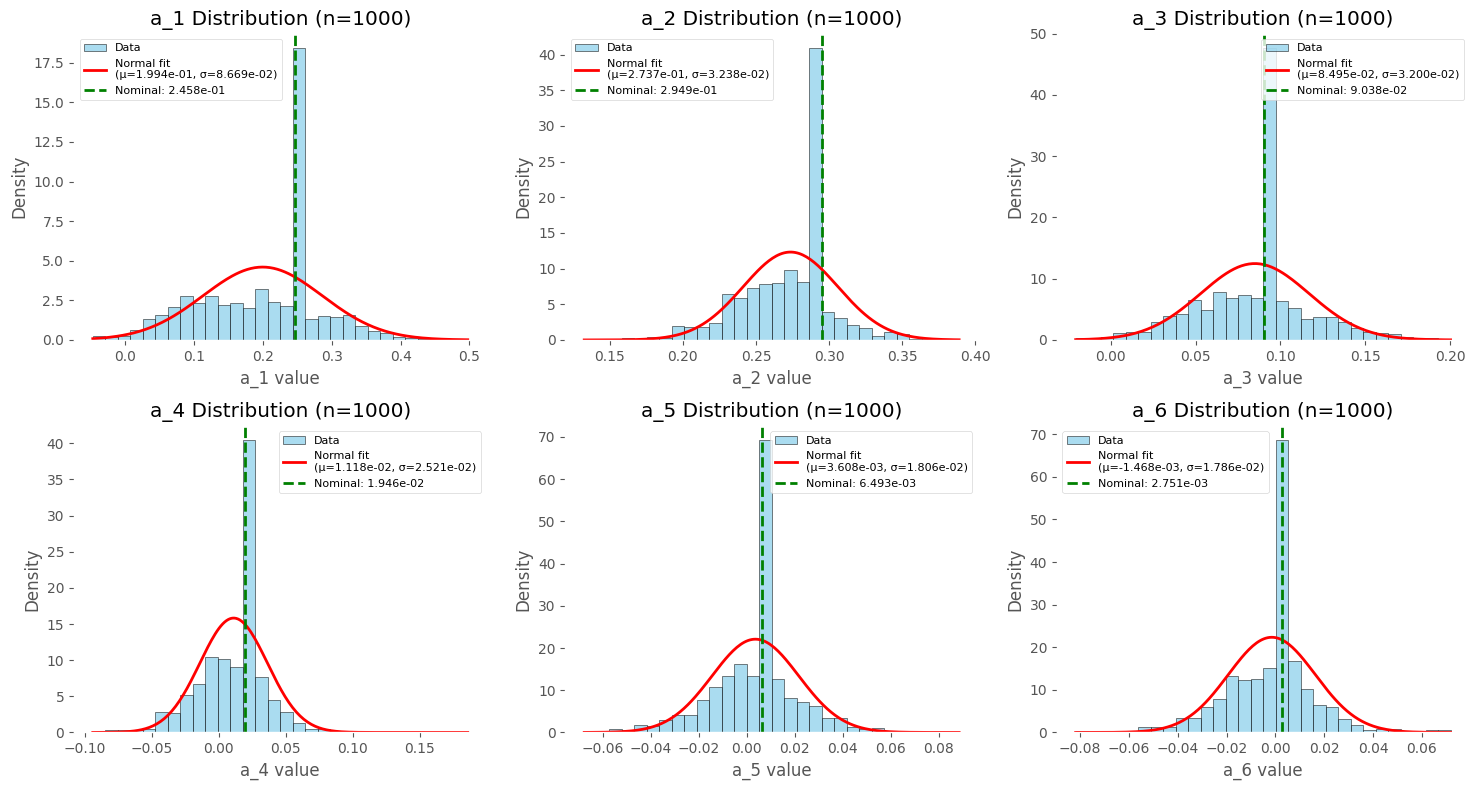

In [10]:
# Cell 9: Visualize distributions - Histograms with normal fit
n_coeffs = len([col for col in coeff_cols if nonzero_masks[col].sum() >= 3])
n_cols = 3
n_rows = int(np.ceil(n_coeffs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

plot_idx = 0
for i, col in enumerate(coeff_cols):
    mask = nonzero_masks[col]
    real_data = df_energy.loc[mask, col].values
    
    if len(real_data) < 3:
        continue
    
    ax = axes[plot_idx]
    
    # Histogram
    n, bins, patches = ax.hist(real_data, bins=30, density=True, alpha=0.7, 
                                color='skyblue', edgecolor='black', label='Data')
    
    # Fitted normal distribution
    mean_val = np.mean(real_data)
    std_val = np.std(real_data, ddof=1)
    x = np.linspace(real_data.min(), real_data.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mean_val, std_val), 'r-', lw=2, 
            label=f'Normal fit\n(μ={mean_val:.3e}, σ={std_val:.3e})')
    
    # Nominal value
    if nominal_coeffs is not None:
        ax.axvline(nominal_coeffs[i], color='green', linestyle='--', lw=2, 
                   label=f'Nominal: {nominal_coeffs[i]:.3e}')
    
    # Formatting
    ax.set_xlabel(f'{col} value')
    ax.set_ylabel('Density')
    ax.set_title(f'{col} Distribution (n={len(real_data)})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    plot_idx += 1

# Hide unused subplots
for idx in range(plot_idx, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

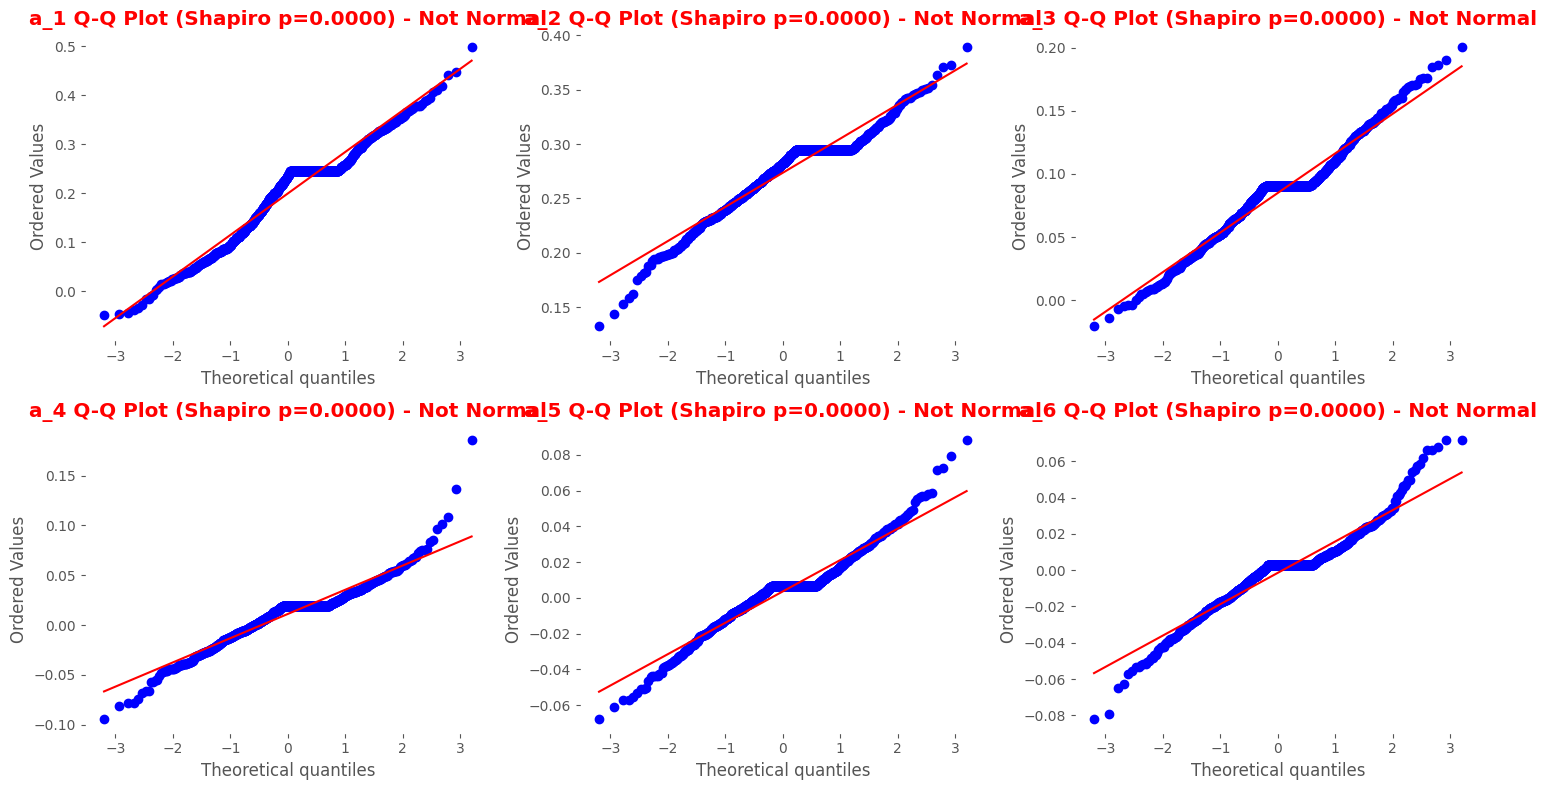

In [11]:
# Cell 10: Q-Q plots (Quantile-Quantile plots against normal distribution)
n_coeffs = len([col for col in coeff_cols if nonzero_masks[col].sum() >= 3])
n_cols = 3
n_rows = int(np.ceil(n_coeffs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

plot_idx = 0
for i, col in enumerate(coeff_cols):
    mask = nonzero_masks[col]
    real_data = df_energy.loc[mask, col].values
    
    if len(real_data) < 3:
        continue
    
    ax = axes[plot_idx]
    
    # Q-Q plot
    stats.probplot(real_data, dist="norm", plot=ax)
    
    # Get p-value from stats_df
    p_shapiro = stats_df.loc[stats_df['coeff'] == col, 'shapiro_p'].values[0]
    is_normal = stats_df.loc[stats_df['coeff'] == col, 'is_normal_shapiro'].values[0]
    
    # Title with test result
    normality_text = "Normal" if is_normal else "Not Normal"
    color = 'green' if is_normal else 'red'
    ax.set_title(f'{col} Q-Q Plot (Shapiro p={p_shapiro:.4f}) - {normality_text}',
                 color=color, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plot_idx += 1

# Hide unused subplots
for idx in range(plot_idx, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

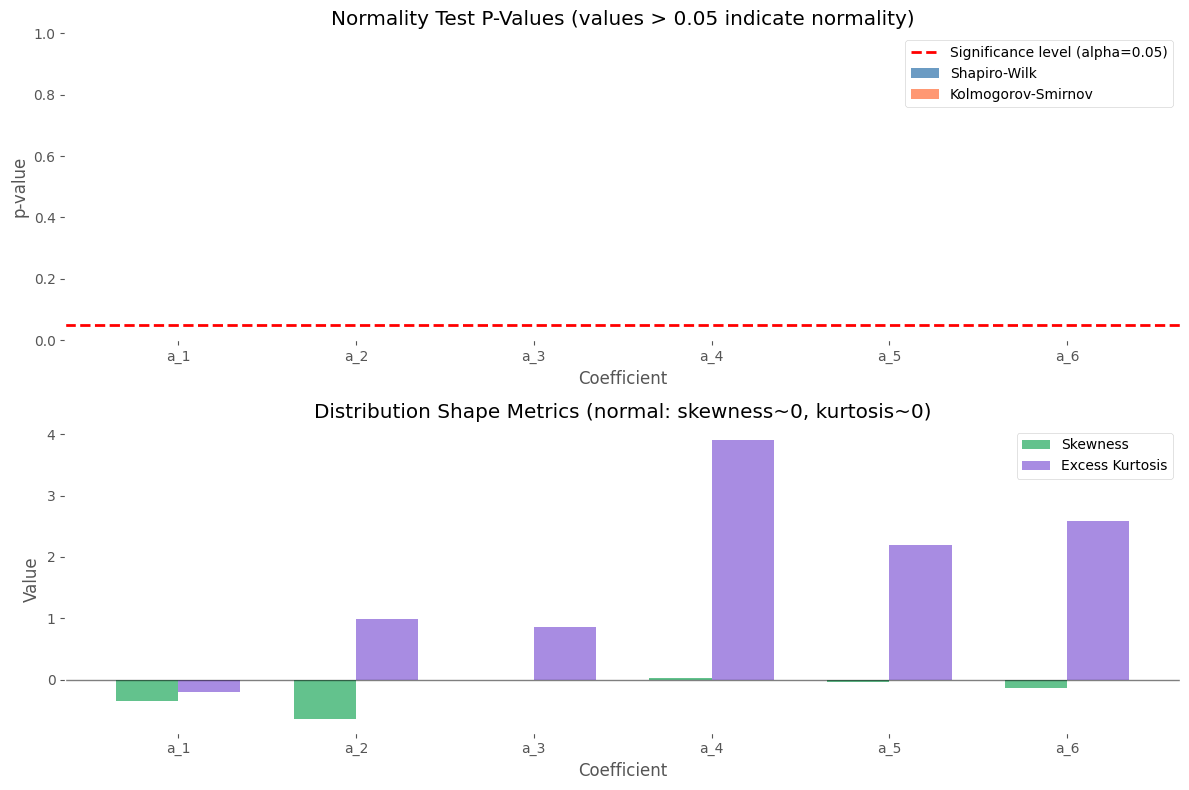

In [12]:
# Cell 11: Summary visualization - Normality test results
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Filter to coefficients with enough data
stats_df_filtered = stats_df[stats_df['n_samples'] >= 3].copy()

# Plot 1: P-values from Shapiro-Wilk and KS tests
ax = axes[0]
x = np.arange(len(stats_df_filtered))
width = 0.35

bars1 = ax.bar(x - width/2, stats_df_filtered['shapiro_p'], width, 
               label='Shapiro-Wilk', alpha=0.8, color='steelblue')
bars2 = ax.bar(x + width/2, stats_df_filtered['ks_p'], width,
               label='Kolmogorov-Smirnov', alpha=0.8, color='coral')

ax.axhline(0.05, color='red', linestyle='--', linewidth=2, 
           label='Significance level (alpha=0.05)')

ax.set_xlabel('Coefficient')
ax.set_ylabel('p-value')
ax.set_title('Normality Test P-Values (values > 0.05 indicate normality)')
ax.set_xticks(x)
ax.set_xticklabels(stats_df_filtered['coeff'], rotation=0)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, max(1.0, stats_df_filtered[['shapiro_p', 'ks_p']].max().max() * 1.1)])

# Plot 2: Skewness and Kurtosis
ax = axes[1]
bars1 = ax.bar(x - width/2, stats_df_filtered['skewness'], width,
               label='Skewness', alpha=0.8, color='mediumseagreen')
bars2 = ax.bar(x + width/2, stats_df_filtered['kurtosis'], width,
               label='Excess Kurtosis', alpha=0.8, color='mediumpurple')

ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax.set_xlabel('Coefficient')
ax.set_ylabel('Value')
ax.set_title('Distribution Shape Metrics (normal: skewness~0, kurtosis~0)')
ax.set_xticks(x)
ax.set_xticklabels(stats_df_filtered['coeff'], rotation=0)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [13]:
# Cell 12: Final summary report
print("=" * 100)
print(f"DISTRIBUTION ANALYSIS SUMMARY - Energy: {selected_energy_mev:.5f} MeV")
print("=" * 100)
print()

# Count how many coefficients pass normality tests
stats_df_filtered = stats_df[stats_df['n_samples'] >= 3].copy()
n_total = len(stats_df_filtered)
n_normal_shapiro = stats_df_filtered['is_normal_shapiro'].sum()
n_normal_ks = stats_df_filtered['is_normal_ks'].sum()

print(f"Coefficients analyzed: {n_total}")
print(f"Coefficients passing Shapiro-Wilk test (p > 0.05): {n_normal_shapiro}/{n_total} ({n_normal_shapiro/n_total*100:.1f}%)")
print(f"Coefficients passing K-S test (p > 0.05):          {n_normal_ks}/{n_total} ({n_normal_ks/n_total*100:.1f}%)")
print()

print("Detailed Results by Coefficient:")
print("-" * 100)

for _, row in stats_df_filtered.iterrows():
    print(f"\n{row['coeff']}:")
    print(f"  Samples (non-padded): {row['n_samples']}")
    print(f"  Mean ± Std:           {row['mean']:.6e} ± {row['std']:.6e}")
    print(f"  Median [Q1, Q3]:      {row['median']:.6e} [{row['q25']:.6e}, {row['q75']:.6e}]")
    print(f"  Nominal value:        {row['nominal_value']:.6e}")
    print(f"  Skewness:             {row['skewness']:.3f}  {'(symmetric)' if abs(row['skewness']) < 0.5 else '(skewed)'}")
    print(f"  Kurtosis:             {row['kurtosis']:.3f}  {'(mesokurtic)' if abs(row['kurtosis']) < 0.5 else ('(leptokurtic)' if row['kurtosis'] > 0 else '(platykurtic)')}")
    print(f"  Shapiro-Wilk:         p = {row['shapiro_p']:.4f}  {'✓ Normal' if row['is_normal_shapiro'] else '✗ Not normal'}")
    print(f"  Kolmogorov-Smirnov:   p = {row['ks_p']:.4f}  {'✓ Normal' if row['is_normal_ks'] else '✗ Not normal'}")

print()
print("=" * 100)
print("INTERPRETATION GUIDE:")
print("=" * 100)
print("• Shapiro-Wilk and K-S tests: p > 0.05 suggests data is consistent with normal distribution")
print("• Skewness: |skewness| < 0.5 indicates roughly symmetric distribution")
print("• Kurtosis: |kurtosis| < 0.5 indicates tails similar to normal distribution")
print("• Q-Q plots: Points close to diagonal line indicate normality")
print("=" * 100)

DISTRIBUTION ANALYSIS SUMMARY - Energy: 1.51000 MeV

Coefficients analyzed: 6
Coefficients passing Shapiro-Wilk test (p > 0.05): 0/6 (0.0%)
Coefficients passing K-S test (p > 0.05):          0/6 (0.0%)

Detailed Results by Coefficient:
----------------------------------------------------------------------------------------------------

a_1:
  Samples (non-padded): 1000
  Mean ± Std:           1.994307e-01 ± 8.669223e-02
  Median [Q1, Q3]:      2.349130e-01 [1.327677e-01, 2.458069e-01]
  Nominal value:        2.458069e-01
  Skewness:             -0.350  (symmetric)
  Kurtosis:             -0.200  (mesokurtic)
  Shapiro-Wilk:         p = 0.0000  ✗ Not normal
  Kolmogorov-Smirnov:   p = 0.0000  ✗ Not normal

a_2:
  Samples (non-padded): 1000
  Mean ± Std:           2.736509e-01 ± 3.238115e-02
  Median [Q1, Q3]:      2.822579e-01 [2.529800e-01, 2.949123e-01]
  Nominal value:        2.949123e-01
  Skewness:             -0.631  (skewed)
  Kurtosis:             0.993  (leptokurtic)
  Shapiro-

In [14]:
# Cell 13: Compare multiple energies (optional extended analysis)
print("Analyzing normality across ALL energy points...")
print()

# Select a subset of energies (e.g., every 5th energy)
selected_energies = energy_summary.iloc[::5]['energy_index'].values[:10]  # Max 10 energies

normality_results = []

for energy_idx in selected_energies:
    energy_mev = energy_summary[energy_summary['energy_index'] == energy_idx]['energy_mev'].values[0]
    
    # Filter data for this energy (excluding nominal)
    df_e = df[(df['energy_index'] == energy_idx) & (df['sample_idx'] > 0)].copy()
    
    if len(df_e) < 3:
        continue
    
    # Get masks for this energy
    masks_e = get_nonzero_mask(df_e, coeff_cols)
    
    # Analyze each coefficient
    for col in coeff_cols:
        mask = masks_e[col]
        real_data = df_e.loc[mask, col].values
        
        if len(real_data) < 3:
            continue
        
        # Run Shapiro-Wilk test
        _, p_value = stats.shapiro(real_data) if len(real_data) <= 5000 else (np.nan, np.nan)
        
        normality_results.append({
            'energy_index': energy_idx,
            'energy_mev': energy_mev,
            'coefficient': col,
            'n_samples': len(real_data),
            'shapiro_p': p_value,
            'is_normal': p_value > 0.05 if not np.isnan(p_value) else False,
        })

norm_df = pd.DataFrame(normality_results)

# Summary by energy
print("\nNormality Test Results Across Energies:")
print("-" * 80)

energy_summary_norm = norm_df.groupby(['energy_index', 'energy_mev']).agg({
    'is_normal': ['sum', 'count'],
    'shapiro_p': 'mean'
}).round(4)

energy_summary_norm.columns = ['n_normal', 'n_total', 'mean_p_value']
energy_summary_norm['pct_normal'] = (energy_summary_norm['n_normal'] / energy_summary_norm['n_total'] * 100).round(1)

print(energy_summary_norm.to_string())

# Summary by coefficient
print("\n\nNormality Test Results Across Coefficients:")
print("-" * 80)

coeff_summary_norm = norm_df.groupby('coefficient').agg({
    'is_normal': ['sum', 'count'],
    'shapiro_p': 'mean'
}).round(4)

coeff_summary_norm.columns = ['n_normal', 'n_total', 'mean_p_value']
coeff_summary_norm['pct_normal'] = (coeff_summary_norm['n_normal'] / coeff_summary_norm['n_total'] * 100).round(1)

print(coeff_summary_norm.to_string())

# Overall summary
overall_normal = norm_df['is_normal'].sum()
overall_total = len(norm_df)

print(f"\n\nOVERALL: {overall_normal}/{overall_total} ({overall_normal/overall_total*100:.1f}%) coefficient-energy combinations pass normality test")

Analyzing normality across ALL energy points...


Normality Test Results Across Energies:
--------------------------------------------------------------------------------
                         n_normal  n_total  mean_p_value  pct_normal
energy_index energy_mev                                             
2376         1.000              0        6           0.0         0.0
2381         1.005              0        5           0.0         0.0
2386         1.010              0        5           0.0         0.0
2391         1.015              0        3           0.0         0.0
2396         1.020              0        4           0.0         0.0
2401         1.025              0        3           0.0         0.0
2406         1.030              0        2           0.0         0.0
2411         1.035              0        2           0.0         0.0
2416         1.040              0        5           0.0         0.0
2421         1.045              0        5           0.0         0.0

